# XGBoost Model Training & Evaluation

This notebook trains and evaluates XGBoost multiclass classifiers on the feature matrix produced by `preprocessing.ipynb`. Two model configurations are compared in an **ablation study**:

| Configuration | Features | Purpose |
|---|---|---|
| **IMU-only** | TSFEL features from 9 IMU channels | Baseline motion-only model |
| **IMU + HR** | IMU features + 5 heart rate summary statistics | Evaluates added value of physiological context |

**Notebook structure:**
1. Load the feature dataset and identify IMU vs. HR features
2. Variance-based feature pre-selection
3. Cross-validation strategy — Leave-One-Set-Out (LOSO-Set)
4. Class imbalance — diagnosis and sample-weight correction
5. Hyperparameter tuning via randomized search
6. LOSO-Set cross-validation evaluation (both configurations)
7. Aggregate evaluation — confusion matrix, precision, recall, F1, balanced accuracy
8. Heart rate ablation comparison
9. Feature importance analysis
10. Final model — train on all data and save to disk

In [1]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import joblib
from sklearn.model_selection import LeaveOneGroupOut, GroupKFold, RandomizedSearchCV
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score)
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "figure.facecolor": "white"})

LABEL_MAP = {0: "rest", 1: "pull-ups", 2: "bicep-curls",
             3: "lateral-raises", 4: "cardio", 5: "squats"}
LABEL_COLORS = {
    0: "#999999", 1: "#e41a1c", 2: "#377eb8",
    3: "#4daf4a", 4: "#ff7f00", 5: "#984ea3",
}
N_CLASSES = len(LABEL_MAP)
RANDOM_STATE = 42

print("Imports loaded.")

Imports loaded.


---
## Step 1 — Load the Feature Dataset

The feature matrix produced by `preprocessing.ipynb` contains one row per 3-second window. Three metadata columns are carried alongside the features:

- **`label`** — integer activity class (0–5)
- **`source_file`** — the recording session the window came from
- **`set_id`** — a unique string identifying the contiguous label run (exercise set or rest bout) the window belongs to within its segment

The `set_id` column is the key enabler of the Leave-One-Set-Out cross-validation strategy used in this notebook.

The feature columns are split into two groups for the ablation study:
- **IMU features** — TSFEL features extracted from the 9 IMU signal channels (accelerometer, gyroscope, and derived magnitude/jerk signals)
- **HR features** — 5 summary statistics of heart rate per window (`hr_mean`, `hr_std`, `hr_min`, `hr_max`, `hr_range`)

In [2]:
df = pd.read_parquet(os.path.join("data", "features.parquet"))

META_COLS = ["label", "source_file", "set_id"]
ALL_FEATURE_COLS = [c for c in df.columns if c not in META_COLS]

# Separate IMU and HR feature columns for the ablation study
HR_FEATURE_COLS  = [c for c in ALL_FEATURE_COLS if c.startswith("hr_")]
IMU_FEATURE_COLS = [c for c in ALL_FEATURE_COLS if c not in HR_FEATURE_COLS]

y       = df["label"].values
groups  = df["set_id"].values

print(f"Dataset: {df.shape[0]:,} windows × {len(ALL_FEATURE_COLS):,} features")
print(f"  IMU features: {len(IMU_FEATURE_COLS):,}")
print(f"  HR features:  {len(HR_FEATURE_COLS)}  {HR_FEATURE_COLS}")
print(f"Unique sets: {df['set_id'].nunique()}")
print()

# Set coverage per class
print(f"{'Class':<20} {'Windows':>8} {'Sets':>6} {'Sessions containing class':>28}")
print("-" * 66)
for lid in sorted(df["label"].unique()):
    sub = df[df["label"] == lid]
    srcs = ", ".join(sorted(sub["source_file"].str.replace("exercise_data_", "S")
                            .str.replace(".csv", "").unique()))
    print(f"{LABEL_MAP[lid]:<20} {len(sub):>8,} {sub['set_id'].nunique():>6}   {srcs}")

Dataset: 2,446 windows × 1,275 features
  IMU features: 1,270
  HR features:  5  ['hr_mean', 'hr_std', 'hr_min', 'hr_max', 'hr_range']
Unique sets: 58

Class                 Windows   Sets    Sessions containing class
------------------------------------------------------------------
rest                      815     30   S0, S1, S2, S3
pull-ups                  311      9   S0, S1, S3
bicep-curls               368      6   S1, S3
lateral-raises            340      7   S1, S3
cardio                    337      2   S2
squats                    275      4   S3


---
## Step 1b — Variance-Based Feature Pre-Selection

### Why reduce feature count before cross-validation?

With 1,200+ features, training a single XGBoost fold is slow. Many TSFEL features have near-zero variance (close to constant across all windows) and carry no discriminative information.

A **variance filter** retains only the `TOP_K` features with the highest variance across the dataset, discarding low-information features without ever looking at the class labels. Because variance is a property of the input distribution alone — not of the labels — applying this filter before splitting into CV folds introduces **no data leakage**.

For the **IMU + HR ablation**, the top-K IMU features are selected, and then all 5 HR features are appended unconditionally. This ensures that HR information is always available to the model regardless of whether HR features would have made the variance-based cut on their own.

In [3]:
TOP_K = 300  # number of highest-variance IMU features to retain

# ── IMU-only feature selection ────────────────────────────────────────────────
X_imu_all = df[IMU_FEATURE_COLS].values
imu_variances = X_imu_all.var(axis=0)
top_k_imu_idx = np.argsort(imu_variances)[-TOP_K:]
X_imu_cv = X_imu_all[:, top_k_imu_idx]
top_k_imu_names = [IMU_FEATURE_COLS[i] for i in top_k_imu_idx]

print(f"IMU-only: {len(IMU_FEATURE_COLS)} → {X_imu_cv.shape[1]} features (top-{TOP_K} by variance)")

# ── IMU + HR feature selection ─────────────────────────────────────────────────
# Top-K IMU features + all HR features appended
X_hr = df[HR_FEATURE_COLS].values
X_imu_hr_cv = np.hstack([X_imu_cv, X_hr])
top_k_imu_hr_names = top_k_imu_names + HR_FEATURE_COLS

print(f"IMU+HR:   {len(ALL_FEATURE_COLS)} → {X_imu_hr_cv.shape[1]} features "
      f"(top-{TOP_K} IMU + {len(HR_FEATURE_COLS)} HR)")

# Store both configurations for easy iteration
CONFIGS = {
    "IMU-only": {"X": X_imu_cv, "names": top_k_imu_names},
    "IMU+HR":   {"X": X_imu_hr_cv, "names": top_k_imu_hr_names},
}

IMU-only: 1270 → 300 features (top-300 by variance)
IMU+HR:   1275 → 305 features (top-300 IMU + 5 HR)


---
## Step 2 — Cross-Validation Strategy: Leave-One-Set-Out (LOSO-Set)

### Why not random k-fold?

Random k-fold cross-validation violates a fundamental assumption of time-series data: **temporal independence**. Because consecutive windows overlap by 50% (75 shared samples), a randomly assigned test window is almost certainly adjacent to a training window that shares the majority of its samples. This constitutes direct data leakage — the model is effectively evaluated on data it has already seen in a slightly shifted form — and leads to optimistically biased accuracy estimates that do not reflect real-world performance on new recordings.

### Why not Leave-One-Session-Out?

Leave-One-Session-Out (LOSO by recording file) is common in HAR literature. However, inspection of this dataset revealed a critical structural problem: **cardio data exists only in session 2, and squats data exists only in session 3**. Holding out session 2 would give the model zero cardio training examples; holding out session 3 would give it zero squats examples. The resulting accuracy metrics would be meaningless for those classes — not a reflection of the model's capacity, but a reflection of missing training data.

### Leave-One-Set-Out: the right choice for this dataset

A **set** is a single contiguous exercise or rest bout (e.g., one set of pull-ups, one rest period). Each set is assigned a unique `set_id` in the feature matrix. In LOSO-Set cross-validation:

- One set is held out as the test fold
- The model trains on all windows from all other sets
- This repeats for every set, yielding one fold per set (58 folds total)

This approach provides two important guarantees:
1. **No data leakage from overlapping windows** — because all windows from a set move together into the test fold, no training window shares samples with a test window
2. **All classes remain in training at every fold** — even when a cardio set is held out, the remaining cardio sets stay in training; the model is never asked to predict a class it has never seen

### Known limitation

LOSO-Set is less conservative than LOSO-Session because windows from the same session (but different sets) share session-level characteristics (sensor calibration, watch position, fatigue state). The LOSO-Set results may therefore be slightly optimistic compared to true session-level holdout. This is acknowledged as a limitation imposed by the single-session representation of cardio and squats, and will improve as more diverse data is collected.

In [4]:
loso = LeaveOneGroupOut()
n_folds = loso.get_n_splits(X_imu_cv, y, groups)
print(f"LOSO-Set folds: {n_folds}  (one per unique set_id)")

# Show the test-set class distribution across folds
fold_labels = []
for train_idx, test_idx in loso.split(X_imu_cv, y, groups):
    test_labels = np.unique(y[test_idx])
    fold_labels.append(set(test_labels))

print(f"\nFolds that evaluate each class (i.e. how often each class appears in test):")
for lid in sorted(LABEL_MAP):
    count = sum(1 for fl in fold_labels if lid in fl)
    print(f"  {LABEL_MAP[lid]:<16}: {count:>3} / {n_folds} folds")

LOSO-Set folds: 58  (one per unique set_id)

Folds that evaluate each class (i.e. how often each class appears in test):
  rest            :  30 / 58 folds
  pull-ups        :   9 / 58 folds
  bicep-curls     :   6 / 58 folds
  lateral-raises  :   7 / 58 folds
  cardio          :   2 / 58 folds
  squats          :   4 / 58 folds


---
## Step 3 — Class Imbalance: Diagnosis and Correction

### The problem

The rest class (~33% of windows) is roughly 2–3× more frequent than each exercise class. If left uncorrected, a classifier can achieve high raw accuracy simply by biasing predictions toward rest, while performing poorly on the exercise classes that matter most for the application.

### The correction: balanced sample weights

Rather than physically resampling the data (oversampling minority classes or undersampling rest), we use **sample weights** — a scalar assigned to each training window that tells the model how much to penalise misclassifying that window. Scikit-learn's `compute_sample_weight("balanced", y)` computes weights inversely proportional to class frequency:

$$w_i = \frac{N}{K \cdot N_{y_i}}$$

where $N$ is the total number of training windows, $K$ is the number of classes, and $N_{y_i}$ is the number of windows in class $y_i$. Sample weights are recomputed **inside each CV fold** using only the training split.

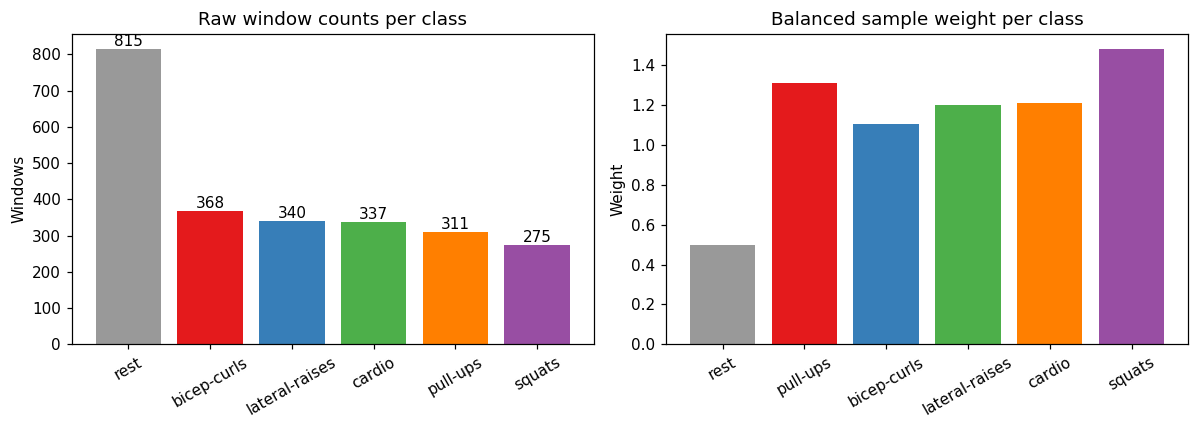

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Raw window counts
counts = pd.Series(y).map(LABEL_MAP).value_counts()
bars = axes[0].bar(counts.index, counts.values,
                   color=[LABEL_COLORS[k] for k, v in LABEL_MAP.items()
                          if v in counts.index])
axes[0].bar_label(bars, fmt="{:.0f}")
axes[0].set_title("Raw window counts per class")
axes[0].set_ylabel("Windows")
axes[0].tick_params(axis="x", rotation=30)

# Corresponding balanced sample weights (computed on full dataset for illustration)
sample_weights_full = compute_sample_weight("balanced", y)
avg_weight_per_class = {LABEL_MAP[lid]: sample_weights_full[y == lid].mean()
                        for lid in sorted(LABEL_MAP)}
axes[1].bar(avg_weight_per_class.keys(), avg_weight_per_class.values(),
            color=[LABEL_COLORS[k] for k in sorted(LABEL_MAP)])
axes[1].set_title("Balanced sample weight per class")
axes[1].set_ylabel("Weight")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

---
## Step 4 — XGBoost Configuration and Hyperparameter Tuning

### Why XGBoost?

XGBoost (eXtreme Gradient Boosting, Chen & Guestrin 2016) is an ensemble method that builds trees sequentially, each correcting the residual errors of its predecessors. For tabular feature data of moderate size — precisely the regime of handcrafted TSFEL features on a few thousand windows — boosted trees consistently outperform neural networks in accuracy, training speed, and robustness to irrelevant features. XGBoost in particular adds regularisation terms (L1 and L2) directly to the tree-building objective, which helps prevent overfitting given our relatively high feature dimensionality.

### Hyperparameter tuning strategy

Rather than relying on manually chosen defaults, we use **randomized search** over a predefined parameter space to find a strong configuration. The tuning procedure:

1. **Search space** — ranges for key hyperparameters (number of trees, learning rate, tree depth, regularisation, subsampling ratios)
2. **Inner CV** — `GroupKFold(n_splits=5)` with `set_id` as groups, using `f1_macro` as the scoring metric. GroupKFold respects the set structure and prevents data leakage during tuning.
3. **Outer evaluation** — the best parameters from the inner CV are then evaluated with full LOSO-Set CV (58 folds) for unbiased performance estimates.

This separation between tuning CV and evaluation CV prevents the hyperparameters from being optimised on the exact same folds used for final reporting, avoiding circular optimisation bias.

Tuning is performed independently for both the **IMU-only** and **IMU+HR** configurations, since the optimal hyperparameters may differ between feature sets.

In [6]:
# ── Hyperparameter search space ────────────────────────────────────────────────
PARAM_DISTRIBUTIONS = {
    "n_estimators":     [50, 100, 150, 200, 300],
    "learning_rate":    [0.01, 0.05, 0.1, 0.2],
    "max_depth":        [3, 4, 5, 6, 8],
    "subsample":        [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.3, 0.5, 0.7, 0.9],
    "min_child_weight": [1, 3, 5, 7],
    "gamma":            [0, 0.1, 0.3, 0.5],
    "reg_alpha":        [0, 0.01, 0.1, 1.0],
    "reg_lambda":       [0.5, 1.0, 2.0, 5.0],
}

# Fixed parameters (not tuned)
FIXED_PARAMS = {
    "objective":    "multi:softprob",
    "eval_metric":  "mlogloss",
    "num_class":    N_CLASSES,
    "tree_method":  "hist",
    "n_jobs":       1,
    "random_state":  RANDOM_STATE,
    "verbosity":    0,
}


def tune_xgboost(X, y, groups, n_iter=30):
    """
    Tune XGBoost hyperparameters using RandomizedSearchCV with GroupKFold.
    Returns (best_params_dict, best_cv_score).
    """
    base_model = XGBClassifier(**FIXED_PARAMS)
    gkf = GroupKFold(n_splits=5)

    search = RandomizedSearchCV(
        base_model,
        PARAM_DISTRIBUTIONS,
        n_iter=n_iter,
        scoring="f1_macro",
        cv=gkf,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=0,
    )
    search.fit(X, y, groups=groups)
    return search.best_params_, search.best_score_


def make_model(params):
    """Create an XGBClassifier with the given tuned parameters + fixed params."""
    return XGBClassifier(**{**FIXED_PARAMS, **params})


print(f"Search space: {len(PARAM_DISTRIBUTIONS)} hyperparameters")
print(f"Tuning budget: 30 random combinations × 5-fold GroupKFold")

Search space: 9 hyperparameters
Tuning budget: 30 random combinations × 5-fold GroupKFold


In [7]:
# ── Tune IMU-only model ────────────────────────────────────────────────────────
print("Tuning IMU-only model...")
t0 = time.time()
best_params_imu, best_score_imu = tune_xgboost(X_imu_cv, y, groups, n_iter=30)
t_imu = time.time() - t0

print(f"  Done in {t_imu:.1f}s")
print(f"  Best GroupKFold macro-F1: {best_score_imu:.4f}")
print(f"  Best parameters:")
for k, v in sorted(best_params_imu.items()):
    print(f"    {k:<20}: {v}")

Tuning IMU-only model...
  Done in 119.6s
  Best GroupKFold macro-F1: 0.8941
  Best parameters:
    colsample_bytree    : 0.3
    gamma               : 0.5
    learning_rate       : 0.01
    max_depth           : 8
    min_child_weight    : 5
    n_estimators        : 100
    reg_alpha           : 1.0
    reg_lambda          : 5.0
    subsample           : 0.6


In [8]:
# ── Tune IMU+HR model ──────────────────────────────────────────────────────────
print("Tuning IMU+HR model...")
t0 = time.time()
best_params_hr, best_score_hr = tune_xgboost(X_imu_hr_cv, y, groups, n_iter=30)
t_hr = time.time() - t0

print(f"  Done in {t_hr:.1f}s")
print(f"  Best GroupKFold macro-F1: {best_score_hr:.4f}")
print(f"  Best parameters:")
for k, v in sorted(best_params_hr.items()):
    print(f"    {k:<20}: {v}")

# Store tuned params for each configuration
CONFIGS["IMU-only"]["params"] = best_params_imu
CONFIGS["IMU+HR"]["params"]   = best_params_hr

Tuning IMU+HR model...
  Done in 114.4s
  Best GroupKFold macro-F1: 0.8176
  Best parameters:
    colsample_bytree    : 0.9
    gamma               : 0.3
    learning_rate       : 0.2
    max_depth           : 5
    min_child_weight    : 3
    n_estimators        : 50
    reg_alpha           : 0
    reg_lambda          : 0.5
    subsample           : 0.8


---
## Step 5 — LOSO-Set Cross-Validation Evaluation

For each configuration (IMU-only and IMU+HR), the full LOSO-Set cross-validation loop:
1. Splits windows into training (all other sets) and test (the held-out set)
2. Computes balanced sample weights on the **training split only**
3. Trains a fresh XGBoost model with the **tuned hyperparameters**
4. Records per-window predictions and true labels for later aggregation

All predictions are concatenated after the loop to form a single aligned prediction vector over the entire dataset, enabling dataset-wide confusion matrix and classification report computation.

In [9]:
def run_loso_cv(X, y, groups, params, config_name="Model"):
    """
    Run full Leave-One-Set-Out cross-validation.
    Returns (y_true, y_pred, results_df) where results_df has per-fold metrics.
    """
    loso = LeaveOneGroupOut()
    n_folds = loso.get_n_splits(X, y, groups)

    all_y_true = np.empty(len(y), dtype=int)
    all_y_pred = np.empty(len(y), dtype=int)
    fold_results = []

    t0 = time.time()
    for fold_idx, (train_idx, test_idx) in enumerate(loso.split(X, y, groups)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        held_out_set    = groups[test_idx][0]

        sw_train = compute_sample_weight("balanced", y_train)

        model = make_model(params)
        model.fit(X_train, y_train, sample_weight=sw_train)

        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)

        fold_results.append({
            "fold":     fold_idx,
            "set_id":   held_out_set,
            "label":    int(y_test[0]),
            "activity": LABEL_MAP[int(y_test[0])],
            "n_test":   len(y_test),
            "accuracy": acc,
        })

        all_y_true[test_idx] = y_test
        all_y_pred[test_idx] = y_pred

        if fold_idx % 10 == 0:
            print(f"  [{config_name}] Fold {fold_idx+1:>3}/{n_folds} | acc: {acc:.3f}")

    elapsed = time.time() - t0
    print(f"  [{config_name}] Done — {n_folds} folds in {elapsed:.1f}s")
    return all_y_true, all_y_pred, pd.DataFrame(fold_results)


def compute_metrics(y_true, y_pred):
    """Compute all evaluation metrics and return as a dict."""
    return {
        "accuracy":          accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1":          f1_score(y_true, y_pred, average="macro",
                                      labels=sorted(LABEL_MAP), zero_division=0),
        "weighted_f1":       f1_score(y_true, y_pred, average="weighted",
                                      labels=sorted(LABEL_MAP), zero_division=0),
    }

print("CV and evaluation functions defined.")

CV and evaluation functions defined.


In [10]:
# ── Run LOSO-Set CV for both configurations ──────────────────────────────────
cv_results = {}

for config_name, cfg in CONFIGS.items():
    print(f"\n{'='*60}")
    print(f"  Running LOSO-Set CV: {config_name}  ({cfg['X'].shape[1]} features)")
    print(f"{'='*60}")
    y_true, y_pred, fold_df = run_loso_cv(
        cfg["X"], y, groups, cfg["params"], config_name
    )
    metrics = compute_metrics(y_true, y_pred)
    cv_results[config_name] = {
        "y_true": y_true, "y_pred": y_pred,
        "fold_df": fold_df, "metrics": metrics,
    }
    print(f"  Accuracy:          {metrics['accuracy']:.4f}")
    print(f"  Balanced accuracy: {metrics['balanced_accuracy']:.4f}")
    print(f"  Macro F1:          {metrics['macro_f1']:.4f}")


  Running LOSO-Set CV: IMU-only  (300 features)
  [IMU-only] Fold   1/58 | acc: 0.833
  [IMU-only] Fold  11/58 | acc: 0.750
  [IMU-only] Fold  21/58 | acc: 0.963
  [IMU-only] Fold  31/58 | acc: 1.000
  [IMU-only] Fold  41/58 | acc: 1.000
  [IMU-only] Fold  51/58 | acc: 1.000
  [IMU-only] Done — 58 folds in 135.6s
  Accuracy:          0.9505
  Balanced accuracy: 0.9511
  Macro F1:          0.9514

  Running LOSO-Set CV: IMU+HR  (305 features)
  [IMU+HR] Fold   1/58 | acc: 1.000
  [IMU+HR] Fold  11/58 | acc: 0.750
  [IMU+HR] Fold  21/58 | acc: 1.000
  [IMU+HR] Fold  31/58 | acc: 1.000
  [IMU+HR] Fold  41/58 | acc: 0.971
  [IMU+HR] Fold  51/58 | acc: 1.000
  [IMU+HR] Done — 58 folds in 85.8s
  Accuracy:          0.9558
  Balanced accuracy: 0.9533
  Macro F1:          0.9572


---
## Step 6 — Per-Fold Results

Each dot below represents one held-out set. Viewing results at this granularity reveals whether accuracy is consistent across sets of the same class or whether some individual sets are systematically harder to predict.

In [11]:
for config_name in CONFIGS:
    results_df = cv_results[config_name]["fold_df"]
    m = cv_results[config_name]["metrics"]

    print(f"\n── {config_name} — Per-activity LOSO-Set accuracy ──")
    print(f"{'Activity':<18} {'Folds':>6} {'Mean Acc':>10} {'Std Acc':>9} {'Min':>7} {'Max':>7}")
    print("-" * 62)
    for act in [LABEL_MAP[i] for i in sorted(LABEL_MAP)]:
        sub = results_df[results_df["activity"] == act]
        if len(sub) == 0:
            continue
        print(f"{act:<18} {len(sub):>6} {sub['accuracy'].mean():>10.3f} "
              f"{sub['accuracy'].std():>9.3f} {sub['accuracy'].min():>7.3f} "
              f"{sub['accuracy'].max():>7.3f}")

    print(f"\n  Overall accuracy    : {m['accuracy']:.4f}")
    print(f"  Balanced accuracy   : {m['balanced_accuracy']:.4f}")
    print(f"  Macro F1-score      : {m['macro_f1']:.4f}")


── IMU-only — Per-activity LOSO-Set accuracy ──
Activity            Folds   Mean Acc   Std Acc     Min     Max
--------------------------------------------------------------
rest                   30      0.897     0.212   0.000   1.000
pull-ups                9      0.984     0.025   0.923   1.000
bicep-curls             6      0.828     0.357   0.100   1.000
lateral-raises          7      0.952     0.031   0.909   1.000
cardio                  2      0.934     0.030   0.913   0.955
squats                  4      0.937     0.033   0.902   0.969

  Overall accuracy    : 0.9505
  Balanced accuracy   : 0.9511
  Macro F1-score      : 0.9514

── IMU+HR — Per-activity LOSO-Set accuracy ──
Activity            Folds   Mean Acc   Std Acc     Min     Max
--------------------------------------------------------------
rest                   30      0.910     0.215   0.000   1.000
pull-ups                9      0.978     0.031   0.923   1.000
bicep-curls             6      0.828     0.357   0.100

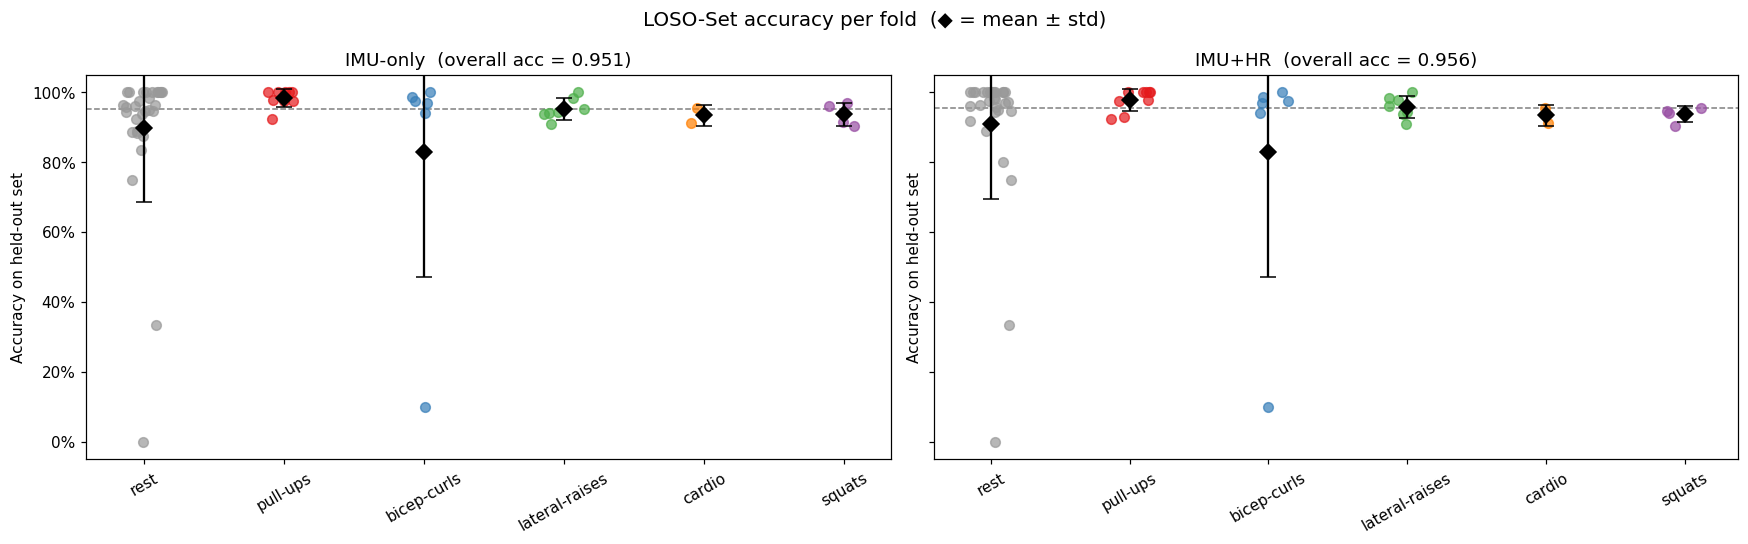

In [12]:
# ── Per-fold accuracy strip plot for both configurations ──────────────────────
activities_ordered = [LABEL_MAP[i] for i in sorted(LABEL_MAP)]
act_positions = {act: i for i, act in enumerate(activities_ordered)}

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, config_name in zip(axes, CONFIGS):
    results_df = cv_results[config_name]["fold_df"]
    overall_acc = cv_results[config_name]["metrics"]["accuracy"]

    for _, row in results_df.iterrows():
        x = act_positions[row["activity"]]
        color = LABEL_COLORS[row["label"]]
        ax.scatter(x + np.random.uniform(-0.15, 0.15), row["accuracy"],
                   color=color, alpha=0.7, s=40, zorder=3)

    for act in activities_ordered:
        sub = results_df[results_df["activity"] == act]
        if len(sub) == 0:
            continue
        x = act_positions[act]
        m, s = sub["accuracy"].mean(), sub["accuracy"].std()
        ax.errorbar(x, m, yerr=s, fmt="D", color="black",
                    markersize=7, capsize=5, zorder=4, linewidth=1.5)

    ax.set_xticks(range(len(activities_ordered)))
    ax.set_xticklabels(activities_ordered, rotation=30)
    ax.set_ylabel("Accuracy on held-out set")
    ax.set_title(f"{config_name}  (overall acc = {overall_acc:.3f})")
    ax.set_ylim(-0.05, 1.05)
    ax.axhline(overall_acc, color="grey", linestyle="--", linewidth=1)
    ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))

plt.suptitle("LOSO-Set accuracy per fold  (◆ = mean ± std)", fontsize=13)
plt.tight_layout()
plt.show()

---
## Step 7 — Aggregate Evaluation

### Confusion matrix and classification report

The confusion matrix pools predictions across all 58 LOSO-Set folds, giving one unified view of how the model performs across the full dataset.

### Metrics reported

| Metric | Description |
|--------|-------------|
| **Accuracy** | Fraction of correctly classified windows |
| **Balanced accuracy** | Mean per-class recall; accounts for class imbalance |
| **Precision** (per-class) | Reliability of each class prediction |
| **Recall** (per-class) | Completeness of detection for each activity |
| **Macro F1** | Harmonic mean of precision and recall, averaged equally across classes |
| **Weighted F1** | F1 weighted by class frequency |

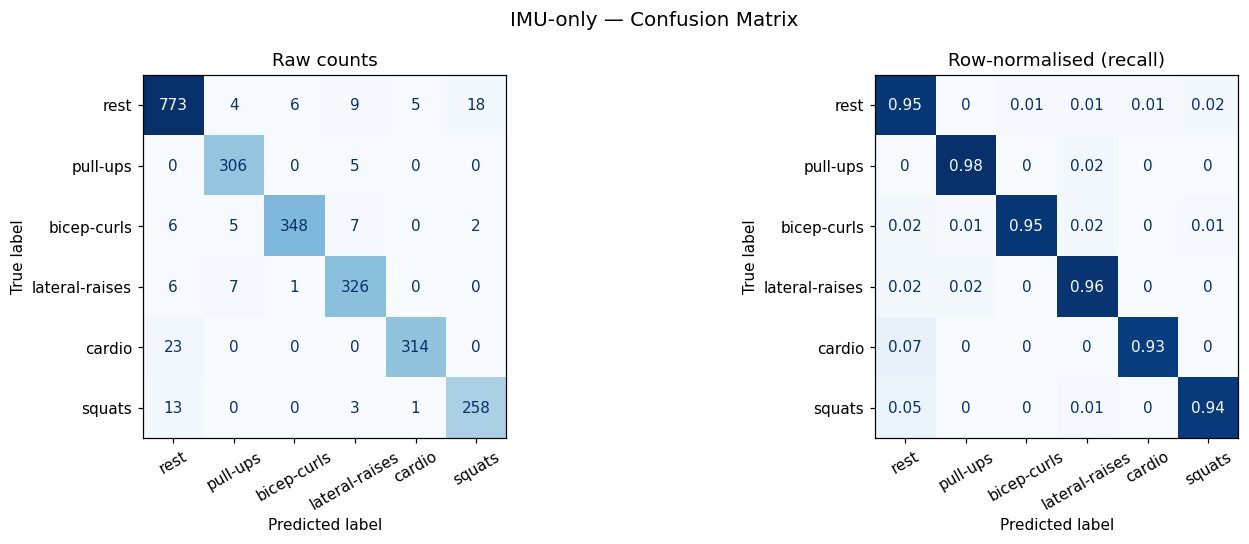


  IMU-only — Classification Report
  Accuracy:          0.9505  (95.1%)
  Balanced accuracy: 0.9511  (95.1%)
  Macro F1:          0.9514
  Weighted F1:       0.9506

                precision    recall  f1-score   support

          rest       0.94      0.95      0.94       815
      pull-ups       0.95      0.98      0.97       311
   bicep-curls       0.98      0.95      0.96       368
lateral-raises       0.93      0.96      0.94       340
        cardio       0.98      0.93      0.96       337
        squats       0.93      0.94      0.93       275

      accuracy                           0.95      2446
     macro avg       0.95      0.95      0.95      2446
  weighted avg       0.95      0.95      0.95      2446



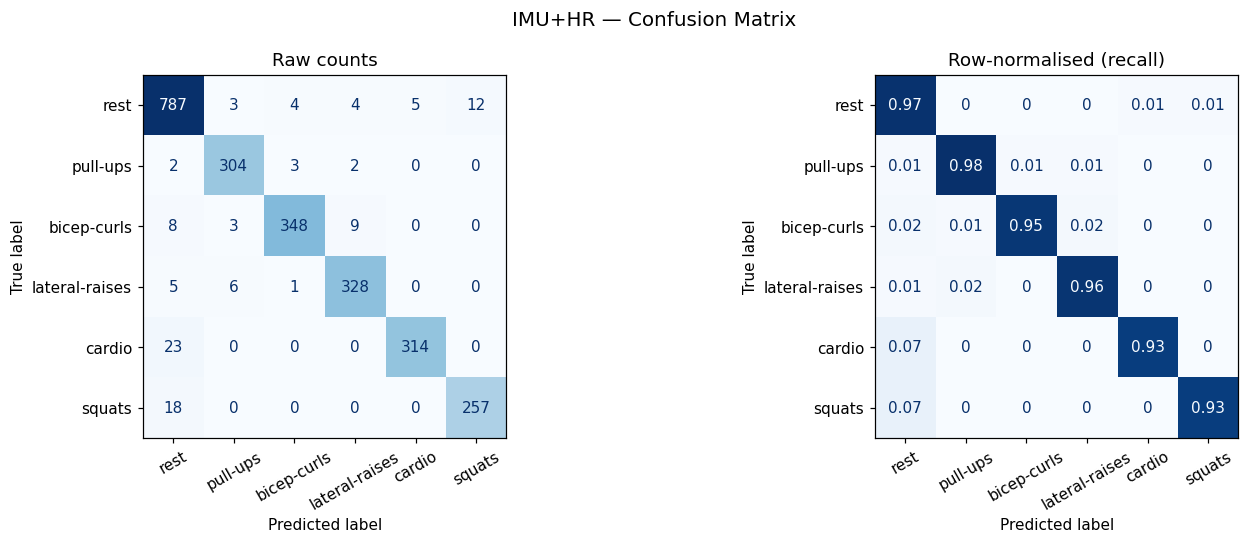


  IMU+HR — Classification Report
  Accuracy:          0.9558  (95.6%)
  Balanced accuracy: 0.9533  (95.3%)
  Macro F1:          0.9572
  Weighted F1:       0.9559

                precision    recall  f1-score   support

          rest       0.93      0.97      0.95       815
      pull-ups       0.96      0.98      0.97       311
   bicep-curls       0.98      0.95      0.96       368
lateral-raises       0.96      0.96      0.96       340
        cardio       0.98      0.93      0.96       337
        squats       0.96      0.93      0.94       275

      accuracy                           0.96      2446
     macro avg       0.96      0.95      0.96      2446
  weighted avg       0.96      0.96      0.96      2446



In [13]:
class_names = [LABEL_MAP[i] for i in sorted(LABEL_MAP)]

for config_name in CONFIGS:
    y_true = cv_results[config_name]["y_true"]
    y_pred = cv_results[config_name]["y_pred"]
    m = cv_results[config_name]["metrics"]

    # Confusion matrices
    cm      = confusion_matrix(y_true, y_pred, labels=sorted(LABEL_MAP))
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{config_name} — Confusion Matrix", fontsize=13)

    disp_raw = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp_raw.plot(ax=axes[0], colorbar=False, cmap="Blues")
    axes[0].set_title("Raw counts")
    axes[0].tick_params(axis="x", rotation=30)

    disp_norm = ConfusionMatrixDisplay(cm_norm.round(2), display_labels=class_names)
    disp_norm.plot(ax=axes[1], colorbar=False, cmap="Blues")
    axes[1].set_title("Row-normalised (recall)")
    axes[1].tick_params(axis="x", rotation=30)

    plt.tight_layout()
    plt.show()

    # Classification report
    print(f"\n{'='*60}")
    print(f"  {config_name} — Classification Report")
    print(f"{'='*60}")
    print(f"  Accuracy:          {m['accuracy']:.4f}  ({m['accuracy']*100:.1f}%)")
    print(f"  Balanced accuracy: {m['balanced_accuracy']:.4f}  ({m['balanced_accuracy']*100:.1f}%)")
    print(f"  Macro F1:          {m['macro_f1']:.4f}")
    print(f"  Weighted F1:       {m['weighted_f1']:.4f}")
    print()
    print(classification_report(y_true, y_pred,
                                labels=sorted(LABEL_MAP),
                                target_names=class_names,
                                zero_division=0))

---
## Step 8 — Heart Rate Ablation Study

### Does heart rate improve activity recognition?

Heart rate provides physiological context that motion sensors alone cannot capture — for example, cardio activities produce elevated heart rates while rest periods show lower values. However, the relationship between HR and activity is indirect and delayed (HR responds to exertion with a lag of several seconds to minutes), and a wrist-worn IMU may already capture sufficient discriminative information from motion patterns alone.

This ablation study directly compares the two model configurations to quantify the marginal contribution of heart rate features. The comparison uses the same LOSO-Set cross-validation procedure, the same class-balanced sample weights, and independently tuned hyperparameters for each configuration.

In [14]:
# ── Side-by-side comparison table ─────────────────────────────────────────────
comparison_rows = []
for config_name in CONFIGS:
    m = cv_results[config_name]["metrics"]
    comparison_rows.append({
        "Configuration":     config_name,
        "Features":          CONFIGS[config_name]["X"].shape[1],
        "Accuracy":          f"{m['accuracy']:.4f}",
        "Balanced Accuracy": f"{m['balanced_accuracy']:.4f}",
        "Macro F1":          f"{m['macro_f1']:.4f}",
        "Weighted F1":       f"{m['weighted_f1']:.4f}",
    })
comp_df = pd.DataFrame(comparison_rows)
print("Heart Rate Ablation — LOSO-Set Cross-Validation Results")
print("=" * 70)
display(comp_df.set_index("Configuration"))

# ── Per-class recall comparison ────────────────────────────────────────────────
print("\nPer-class recall comparison:")
print(f"{'Class':<18} {'IMU-only':>10} {'IMU+HR':>10} {'Delta':>10}")
print("-" * 52)
for lid in sorted(LABEL_MAP):
    y_t = cv_results["IMU-only"]["y_true"]
    mask = y_t == lid
    recall_imu = accuracy_score(y_t[mask], cv_results["IMU-only"]["y_pred"][mask])
    recall_hr  = accuracy_score(y_t[mask], cv_results["IMU+HR"]["y_pred"][mask])
    delta = recall_hr - recall_imu
    arrow = "↑" if delta > 0.001 else ("↓" if delta < -0.001 else "=")
    print(f"{LABEL_MAP[lid]:<18} {recall_imu:>10.3f} {recall_hr:>10.3f} "
          f"{delta:>+10.3f} {arrow}")

Heart Rate Ablation — LOSO-Set Cross-Validation Results


,Features,Accuracy,Balanced Accuracy,Macro F1,Weighted F1
Configuration,,,,,
IMU-only,300,0.9505,0.9511,0.9514,0.9506
IMU+HR,305,0.9558,0.9533,0.9572,0.9559



Per-class recall comparison:
Class                IMU-only     IMU+HR      Delta
----------------------------------------------------
rest                    0.948      0.966     +0.017 ↑
pull-ups                0.984      0.977     -0.006 ↓
bicep-curls             0.946      0.946     +0.000 =
lateral-raises          0.959      0.965     +0.006 ↑
cardio                  0.932      0.932     +0.000 =
squats                  0.938      0.935     -0.004 ↓


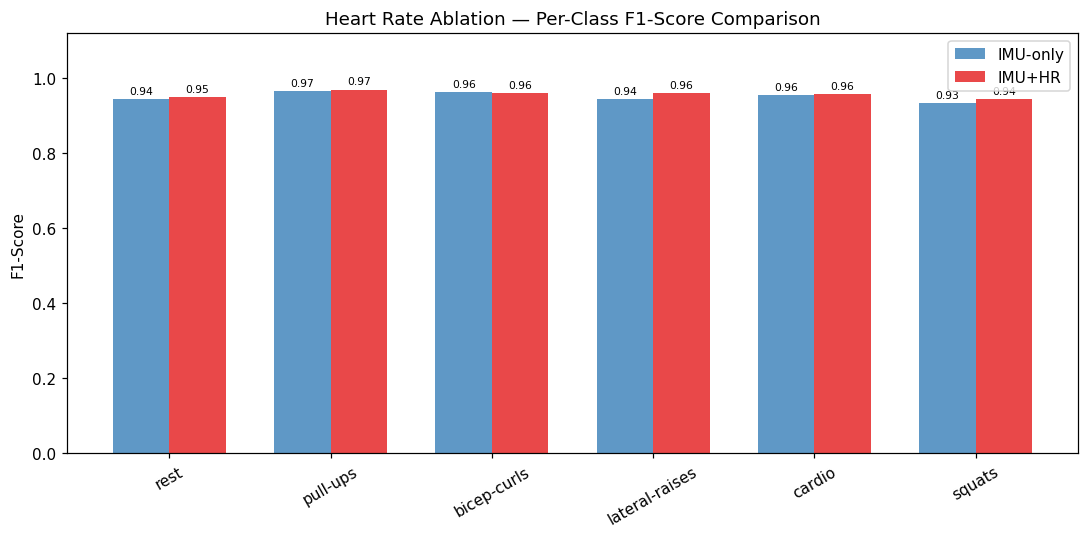

In [15]:
# ── Visual comparison: grouped bar chart of per-class F1 ──────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(class_names))
width = 0.35

for i, config_name in enumerate(CONFIGS):
    y_t = cv_results[config_name]["y_true"]
    y_p = cv_results[config_name]["y_pred"]
    per_class_f1 = f1_score(y_t, y_p, average=None,
                            labels=sorted(LABEL_MAP), zero_division=0)
    offset = -width/2 + i * width
    bars = ax.bar(x + offset, per_class_f1, width, label=config_name,
                  alpha=0.8, color=["#377eb8", "#e41a1c"][i])
    ax.bar_label(bars, fmt="{:.2f}", fontsize=7, padding=2)

ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=30)
ax.set_ylabel("F1-Score")
ax.set_title("Heart Rate Ablation — Per-Class F1-Score Comparison")
ax.set_ylim(0, 1.12)
ax.legend()
plt.tight_layout()
plt.show()

---
## Step 9 — Feature Importance Analysis

### What XGBoost feature importance measures

XGBoost tracks how much each feature contributed to reducing the model's loss across all trees. We use **gain** as the importance metric — the average improvement in loss brought by splits on that feature, averaged across all trees in which it appears.

Importance is computed from the **IMU+HR model** trained on all available data (no held-out fold), which gives the most stable estimate of feature relevance and allows us to see where heart rate features rank among the IMU features.

In [16]:
# Train final model on ALL data with the IMU+HR configuration for importance analysis
# Use all original features (not variance-reduced) for the fullest picture
X_all_feats = df[ALL_FEATURE_COLS].values
sw_all = compute_sample_weight("balanced", y)

final_model = make_model(CONFIGS["IMU+HR"]["params"])
final_model.set_params(n_estimators=300)  # more trees for the final model
final_model.fit(X_all_feats, y, sample_weight=sw_all)

importance_scores = final_model.get_booster().get_score(importance_type="gain")
importance_df = (pd.DataFrame(
                    {"feature": list(importance_scores.keys()),
                     "gain":    list(importance_scores.values())})
                 .sort_values("gain", ascending=False)
                 .reset_index(drop=True))

# Map f0, f1, ... back to actual feature names
importance_df["feature_name"] = importance_df["feature"].apply(
    lambda f: ALL_FEATURE_COLS[int(f[1:])] if f.startswith("f") else f
)

# Flag HR features
importance_df["is_hr"] = importance_df["feature_name"].str.startswith("hr_")

print(f"Features with non-zero importance: {len(importance_df)} / {len(ALL_FEATURE_COLS)}")
hr_imp = importance_df[importance_df["is_hr"]]
print(f"HR features in importance ranking: {len(hr_imp)}")
if len(hr_imp) > 0:
    print(f"\nHR feature ranks and gain:")
    for _, row in hr_imp.iterrows():
        rank = importance_df.index.get_loc(row.name) + 1
        print(f"  #{rank:>4d}  {row['feature_name']:<12}  gain={row['gain']:.3f}")

print(f"\nTop 20 features by gain:")
display(importance_df[["feature_name", "gain", "is_hr"]].head(20))

Features with non-zero importance: 463 / 1275
HR features in importance ranking: 4

HR feature ranks and gain:
  #  47  hr_mean       gain=10.393
  #  63  hr_max        gain=8.235
  # 428  hr_min        gain=0.375
  # 443  hr_std        gain=0.338

Top 20 features by gain:


,feature_name,gain,is_hr
0,gyr_y_Area under the curve,158.877319,False
1,gyr_z_Power bandwidth,144.263000,False
2,acc_x_Zero crossing rate,105.340919,False
3,gyr_y_Fundamental frequency,101.586105,False
4,gyr_z_MFCC_2,96.877487,False
5,acc_z_Spectral centroid,93.458694,False
6,acc_z_Median absolute diff,86.552864,False
7,gyr_y_Absolute energy,80.629417,False
8,gyro_mag_Median absolute diff,79.476540,False
9,acc_x_Median absolute diff,60.517006,False


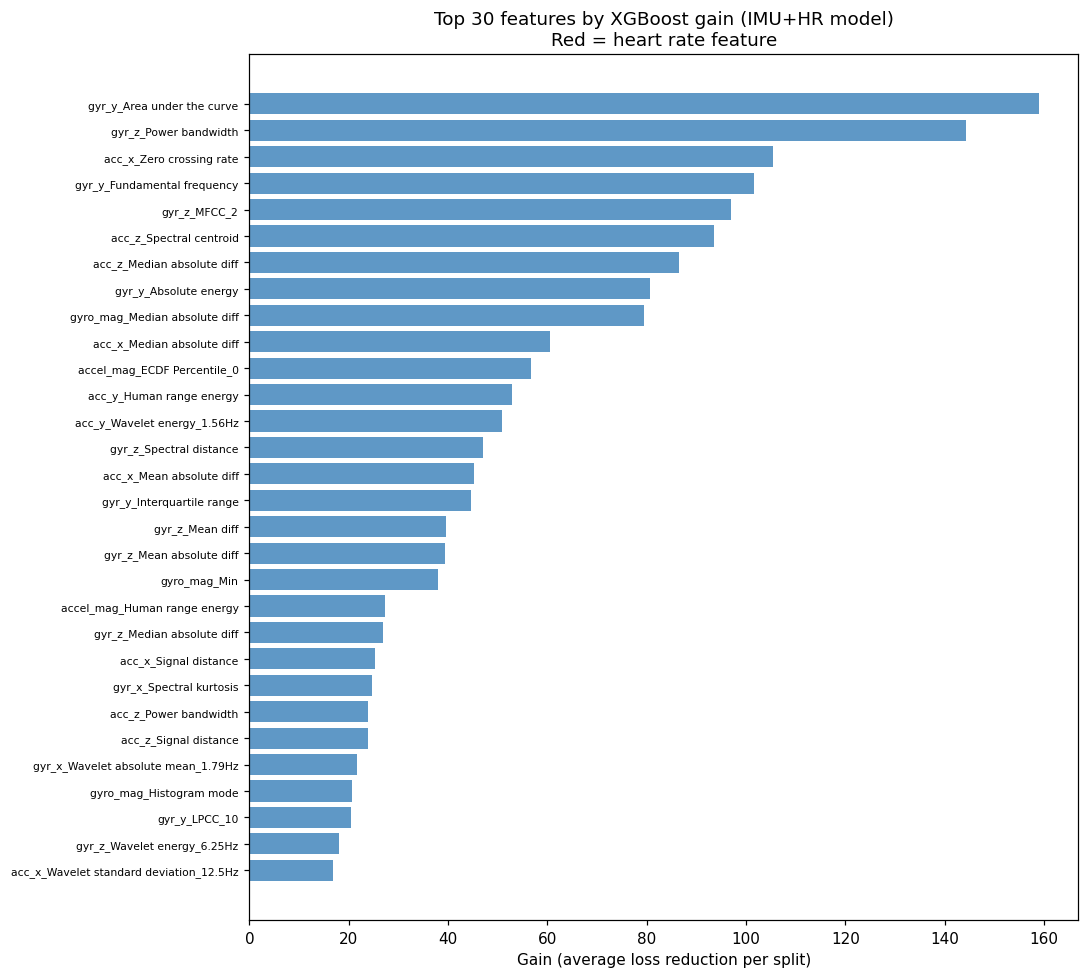

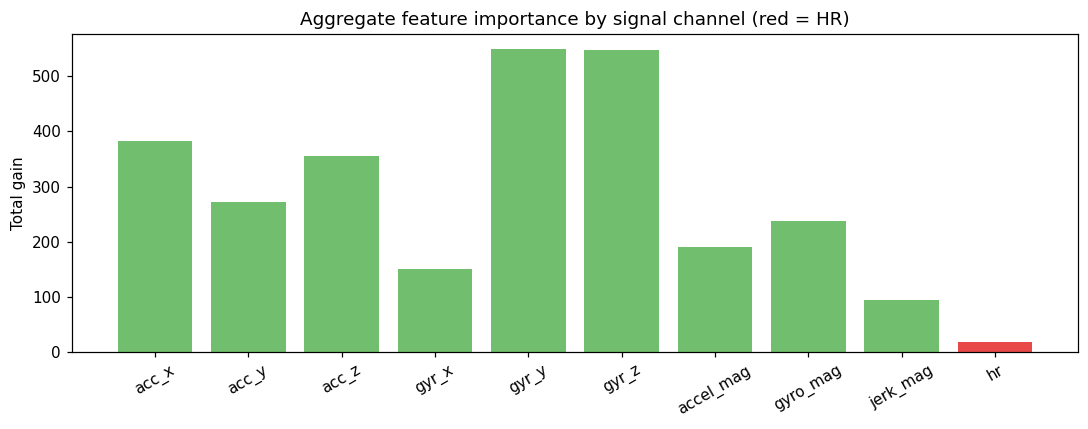

In [17]:
# ── Top-30 features bar chart (HR features highlighted) ────────────────────────
top_n = 30
top_feats = importance_df.head(top_n)

colors = ["#e41a1c" if hr else "#377eb8"
          for hr in top_feats["is_hr"]]

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(range(top_n), top_feats["gain"].values, color=colors, alpha=0.8)
ax.set_yticks(range(top_n))
ax.set_yticklabels([n[:65] for n in top_feats["feature_name"]], fontsize=7)
ax.invert_yaxis()
ax.set_xlabel("Gain (average loss reduction per split)")
ax.set_title(f"Top {top_n} features by XGBoost gain (IMU+HR model)\n"
             "Red = heart rate feature")
plt.tight_layout()
plt.show()

# ── Gain by signal channel ────────────────────────────────────────────────────
channel_order = ["acc_x", "acc_y", "acc_z",
                 "gyr_x", "gyr_y", "gyr_z",
                 "accel_mag", "gyro_mag", "jerk_mag", "hr"]

def channel_from_name(fname):
    if fname.startswith("hr_"):
        return "hr"
    for ch in channel_order:
        if fname.startswith(ch + "_"):
            return ch
    return "other"

importance_df["channel"] = importance_df["feature_name"].apply(channel_from_name)
by_channel = (importance_df.groupby("channel")["gain"].sum()
              .reindex(channel_order, fill_value=0))

ch_colors = ["#e41a1c" if ch == "hr" else "#4daf4a" for ch in by_channel.index]
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(by_channel.index, by_channel.values, color=ch_colors, alpha=0.8)
ax.set_ylabel("Total gain")
ax.set_title("Aggregate feature importance by signal channel (red = HR)")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

---
## Step 10 — Final Model: Train on All Data and Save

### Why train a final model on all data?

The LOSO-Set cross-validation procedure is used exclusively for **evaluation** — estimating how well the model generalises to unseen exercise sets. The CV models themselves (one per fold) are discarded after their test predictions are collected, because each was trained on only a subset of the available data.

For **deployment** — i.e., the model that would actually be run on new Apple Watch recordings — we train a single final model on the entire dataset. This model benefits from all windows and all sets, giving it the most comprehensive view of the signal space. Its expected real-world performance is estimated by the aggregate CV metrics computed above.

Both model configurations (IMU-only and IMU+HR) are saved so that deployment can choose based on heart rate availability.

In [18]:
os.makedirs("models", exist_ok=True)

# The IMU+HR final model was already trained in the importance step above.
# Now also train the IMU-only final model.
X_imu_all = df[IMU_FEATURE_COLS].values
final_model_imu = make_model(CONFIGS["IMU-only"]["params"])
final_model_imu.set_params(n_estimators=300)
final_model_imu.fit(X_imu_all, y, sample_weight=sw_all)

# Save both models
models_to_save = {
    "xgboost_imu_only": final_model_imu,
    "xgboost_imu_hr":   final_model,
}

for name, mdl in models_to_save.items():
    json_path   = f"models/{name}.json"
    joblib_path = f"models/{name}.joblib"
    mdl.save_model(json_path)
    joblib.dump(mdl, joblib_path)
    print(f"  {json_path:<35} ({os.path.getsize(json_path)/1024:.0f} KB)")
    print(f"  {joblib_path:<35} ({os.path.getsize(joblib_path)/1024:.0f} KB)")

# Also save tuned hyperparameters for reproducibility
tuned_params = {
    "IMU-only": CONFIGS["IMU-only"]["params"],
    "IMU+HR":   CONFIGS["IMU+HR"]["params"],
}
joblib.dump(tuned_params, "models/tuned_hyperparameters.joblib")
print(f"  {'models/tuned_hyperparameters.joblib':<35}")

# ── Final summary ──────────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"  LOSO-Set CV Summary")
print(f"{'='*60}")
for config_name in CONFIGS:
    m = cv_results[config_name]["metrics"]
    print(f"\n  {config_name}:")
    print(f"    Accuracy          : {m['accuracy']:.4f}  ({m['accuracy']*100:.1f}%)")
    print(f"    Balanced accuracy : {m['balanced_accuracy']:.4f}  ({m['balanced_accuracy']*100:.1f}%)")
    print(f"    Macro F1-score    : {m['macro_f1']:.4f}")
print(f"\n  Folds (sets)      : {n_folds}")
print(f"  Total windows     : {len(y):,}")
print(f"  IMU features      : {len(IMU_FEATURE_COLS):,}")
print(f"  HR features       : {len(HR_FEATURE_COLS)}")
print(f"{'='*60}")

  models/xgboost_imu_only.json        (1922 KB)
  models/xgboost_imu_only.joblib      (1918 KB)
  models/xgboost_imu_hr.json          (915 KB)
  models/xgboost_imu_hr.joblib        (1315 KB)
  models/tuned_hyperparameters.joblib

  LOSO-Set CV Summary

  IMU-only:
    Accuracy          : 0.9505  (95.1%)
    Balanced accuracy : 0.9511  (95.1%)
    Macro F1-score    : 0.9514

  IMU+HR:
    Accuracy          : 0.9558  (95.6%)
    Balanced accuracy : 0.9533  (95.3%)
    Macro F1-score    : 0.9572

  Folds (sets)      : 58
  Total windows     : 2,446
  IMU features      : 1,270
  HR features       : 5
